<a href="https://colab.research.google.com/github/MoraesAma/Insurance-/blob/main/Amaranta_Moraes_MVP_ML_Analytics_20261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Amaranta Cunha de Moraes

**Matrícula:** 4052025002621

**Data:** 04/07/2026

**Dataset:** Stroke Prediction Dataset
https://raw.githubusercontent.com/MoraesAma/Insurance-/refs/heads/main/healthcare-dataset-stroke-data.csv

**Tipo de problema:** Classificação






# 1. Definição do problema

## 1.1 Descrição do problema

Contextualização do Problema


O problema abordado neste MVP consiste na análise de múltiplos fatores de risco clínicos e demográficos coletados de pacientes para mapear e rastrear a probabilidade de ocorrência de um evento de AVC. O conjunto de dados selecionado simula um cenário epidemiológico real, trazendo desafios analíticos clássicos:
1. **Dados Ausentes:** Registros clínicos incompletos na variável de Índice de Massa Corporal (IMC), que exigirão técnicas estatísticas de imputação.
2. **Desbalanceamento de Classes:** A imensa maioria da população amostrada não sofreu um AVC. Ignorar essa característica faria com que qualquer algoritmo tendesse a ignorar a classe minoritária, que é justamente a de maior interesse.

A abordagem deste cenário por meio de Analytics e Machine Learning permite que o sistema identifique padrões complexos e interações não-lineares ocultas entre as variáveis.



## 1.2 Objetivo do MVP

O objetivo central deste MVP é construir, calibrar e documentar um pipeline completo de Machine Learning capaz de classificar de forma automatizada e precisa se um paciente apresenta ou não um risco iminente de sofrer um AVC, baseado em dados epidemiológicos.




## 1.3 Tipo de problema


Este projeto caracteriza-se tecnicamente como um problema de **Aprendizado de Máquina Supervisionado**, voltado para uma tarefa de **Classificação Binária**.

A natureza supervisionada se dá pelo fato de o algoritmo ser treinado utilizando um conjunto de dados histórico que já contém o rótulo real do desfecho clínico de cada paciente. A tarefa é de classificação binária porque a nossa variável-alvo (`stroke`) é categórica discreta e restrita a duas classes mutuamente exclusivas:
* **Classe 0 (Negativa):** O paciente não sofreu um AVC.
* **Classe 1 (Positiva):** O paciente sofreu um AVC.


## 1.4 Premissas, hipóteses e critérios de sucesso

#### Premissas Clínicas e Hipóteses de Modelagem
* **Premissa 1:** Fatores biológicos crônicos e cumulativos, como idade avançada, histórico de hipertensão arterial e doenças cardíacas crônicas, terão os maiores pesos estatísticos (correlação) na determinação da classe positiva (`stroke` = 1).
* **Premissa 2:** Variáveis de estilo de vida, como o status de tabagismo, agem como fatores catalisadores e multiplicadores de risco quando associados a um Índice de Massa Corporal (IMC) elevado ou a níveis descontrolados de glicose no sangue.
* **Hipótese:** Modelos baseados em árvores e *ensembles* (como Random Forest) apresentarão um desempenho superior ao modelo linear baseline (Regressão Logística), devido à sua habilidade intrínseca de mapear interações não-lineares complexas sem a necessidade de transformações matemáticas prévias nas *features*.

#### Critérios de Sucesso
Devido ao desbalanceamento das classes, a **Acurácia tradicional não será adotada como critério de sucesso**, visto que um modelo que classificasse todos os pacientes como "0" obteria uma acurácia alta, porém seria clinicamente inútil por não detectar nenhum caso real da doença.

Dessa forma, os critérios formais de sucesso estabelecidos são:
1. **Recall na Classe 1:** Minimizar ao máximo a ocorrência de Falsos Negativos;
2. **Equilíbrio via F1-Score:** Maximizar a média harmônica entre Precisão e Recall na classe minoritária;
3. **Métrica de Discriminação (AUC-ROC):** Obter uma área sob a curva ROC superior a 0.80.



# 2. Ambiente, bibliotecas e reprodutibilidade


Abaixo, realizamos a importação centralizada de todas as bibliotecas necessárias para o projeto.


In [ ]:

# Importação de bibliotecas para manipulação e análise de dados
import pandas as pd
import numpy as np

# Importação de bibliotecas para visualização gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Importação de ferramentas do Scikit-Learn para modelagem e pré-processamento
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Importação dos algoritmos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Importação de métricas de avaliação de classificação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Configurações globais do ambiente
import warnings
warnings.filterwarnings('ignore') # Ocultar avisos de atualizações

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Definição de semente global para reprodutibilidade
SEED = 42
np.random.seed(SEED)

print("Todas as bibliotecas e configurações foram carregadas!")

Todas as bibliotecas e configurações foram carregadas!


## 2.1 Funções auxiliares


Criamos nesta seção uma função auxiliar chamada `avaliar_modelo`.

Esta função automatiza o cálculo e a exibição das principais métricas de classificação requeridas pelos nossos critérios de sucesso (Recall, F1-Score, Matriz de Confusão e AUC-ROC).

In [ ]:

def avaliar_modelo(nome_modelo, y_real, y_pred, y_prob):
    """
    Função auxiliar para calcular, imprimir e exibir graficamente as métricas
    de avaliação do modelo.
    """
    # Cálculo das métricas básicas
    acuracia = accuracy_score(y_real, y_pred)
    precisao = precision_score(y_real, y_pred)
    recall = recall_score(y_real, y_pred)
    f1 = f1_score(y_real, y_pred)
    auc = roc_auc_score(y_real, y_prob)

    print(f"==================================================")
    print(f"📊 DESEMPENHO DO MODELO: {nome_modelo.upper()}")
    print(f"==================================================")
    print(f"Acurácia Geral: {acuracia:.4f}")
    print(f"Precisão (Classe 1): {precisao:.4f}")
    print(f"Recall / Sensibilidade (Classe 1): {recall:.4f}")
    print(f"F1-Score (Classe 1): {f1:.4f}")
    print(f"Área sob a Curva ROC (AUC-ROC): {auc:.4f}")
    print(f"==================================================")

    # Exibição do relatório de classificação completo do Scikit-Learn
    print("\n📝 Relatório de Classificação Detalhado:")
    print(classification_report(y_real, y_pred, target_names=['Sem AVC', 'Com AVC']))

    # Plotagem da Matriz de Confusão
    cm = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Previsto Sem AVC', 'Previsto Com AVC'],
                yticklabels=['Real Sem AVC', 'Real Com AVC'])
    plt.title(f'Matriz de Confusão - {nome_modelo}')
    plt.tight_layout()
    plt.show()

    # Retorna as métricas em formato de dicionário para posterior comparação em tabela
    return {
        'Modelo': nome_modelo,
        'Acurácia': acuracia,
        'Precisão': precisao,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc
    }

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Os dados utilizados neste projeto derivam do **Stroke Prediction Dataset**, disponibilizado publicamente na plataforma Kaggle.

* **Contexto dos Dados:** O conjunto de dados contém parâmetros vitais, demográficos e de estilo de vida de pacientes.
* **Atributos:** A base dispõe de 12 variáveis, abrangendo desde fatores como idade, género e índice de massa corporal (IMC), até indicadores de condições crónicas (hipertensão, doenças cardíacas).
* **Variável-Alvo:** A coluna `stroke`, onde o valor 1 indica a ocorrência de um Acidente Vascular Cerebral e 0 a sua ausência.

## 3.2 Carga dos dados




In [ ]:
url_dataset = 'https://raw.githubusercontent.com/MoraesAma/Insurance-/main/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(url_dataset)
display(df.head(3))

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1


## 3.3 Visão geral do dataset


In [ ]:
print("--- 1. Dimensões do Dataset ---")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")

print("\n--- 2. Tipos de Atributos e Nulos ---")
df.info()

print("\n--- 3. Verificação de Duplicatas ---")
print(f"Total de linhas duplicadas: {df.duplicated().sum()}")

print("\n--- 4. Variáveis que não devem ir para o modelo ---")
if 'id' in df.columns:
    print("A coluna 'id' foi identificada e será removida na etapa de preparação de dados.")

print("\n--- 5. Distribuição do Target (stroke) ---")
print(df['stroke'].value_counts(normalize=True) * 100) # Exibindo em percentual para destacar o desbalanceamento

--- 1. Dimensões do Dataset ---
Linhas: 5110 | Colunas: 12

--- 2. Tipos de Atributos e Nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

--- 3. Verificação de Duplicatas ---
Total de linhas dupli

In [ ]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [ ]:
display(df.sample(5, random_state=SEED))

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4688,40041,Male,31.0,0,0,No,Self-employed,Rural,64.85,23.0,Unknown,0
4478,55244,Male,40.0,0,0,Yes,Self-employed,Rural,65.29,28.3,never smoked,0
3849,70992,Female,8.0,0,0,No,children,Urban,74.42,22.5,Unknown,0
4355,38207,Female,79.0,1,0,Yes,Self-employed,Rural,76.64,19.5,never smoked,0
3826,8541,Female,75.0,0,0,Yes,Govt_job,Rural,94.77,27.2,never smoked,0


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| **id** | numérica | Identificador único do paciente. | não | Apenas controle de sistema; não possui qualquer valor ou relação preditiva com a doença. |
| **gender** | categórica | Género do paciente (Male, Female, Other). | sim | Necessitará de codificação (One-Hot Encoding). |
| **age** | numérica | Idade do paciente em anos. | sim | Fator biológico crítico para risco de AVC. |
| **hypertension** | numérica (binária) | Hipertensão arterial (0 = Não, 1 = Sim). | sim | Já em formato numérico. |
| **heart_disease** | numérica (binária) | Doença cardíaca prévia (0 = Não, 1 = Sim). | sim | Já em formato numérico. |
| **ever_married** | categórica | Indica se o paciente é ou já foi casado (Yes/No). | sim | Necessitará de codificação. |
| **work_type** | categórica | Setor de trabalho (Private, Self-employed, Govt_job, etc.). | sim | Necessitará de codificação. |
| **Residence_type** | categórica | Tipo de ambiente onde reside (Urban/Rural). | sim | Necessitará de codificação. |
| **avg_glucose_level** | numérica | Nível médio de glicose no sangue. | sim | Variável contínua relevante clinicamente. |
| **bmi** | numérica | Índice de Massa Corporal (IMC). | sim | **Atenção:** Possui valores ausentes que necessitarão de imputação na fase de pré-processamento. |
| **smoking_status** | categórica | Hábitos de tabagismo. | sim | Necessitará de codificação. |
| **stroke** | alvo | Indicador de ocorrência de AVC (0 = Não, 1 = Sim). | alvo | É a nossa variável dependente (target). Apresenta forte desbalanceamento. |

# 4. Análise exploratória dos dados


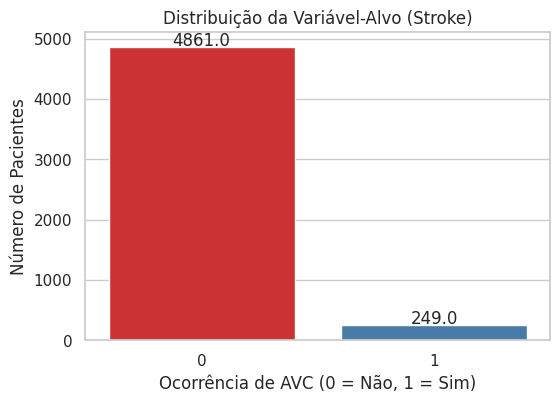

In [ ]:
# Desbalanceamento
# 1. Gráfico de distribuição da variável-alvo
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='stroke', palette='Set1')
plt.title('Distribuição da Variável-Alvo (Stroke)')
plt.xlabel('Ocorrência de AVC (0 = Não, 1 = Sim)')
plt.ylabel('Número de Pacientes')

# Adicionando os rótulos de dados no gráfico
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

**Análise do Target e Desbalanceamento:**
O gráfico acima demonstra o **desbalanceamento** da base. Apenas cerca de 5% dos pacientes (249) do dataset sofreram um AVC.
* **Impacto na modelagem:** Isso confirma que não podemos usar a Acurácia como métrica principal. Um modelo que chute "0" para todos acertaria 95% das vezes, mas falharia na sua função primária de detectar doentes. Além disso, exigirá que a separação entre treino e teste seja estratificada (`stratify=y`) para garantir que os casos raros de AVC não fiquem de fora do treinamento.

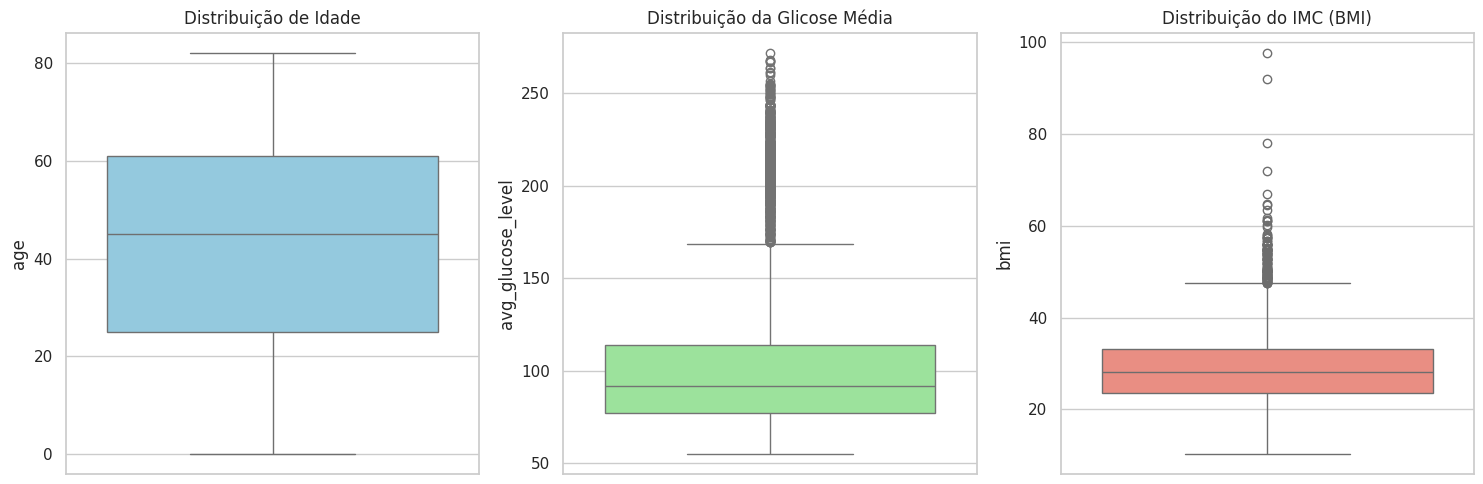

In [ ]:
# Boxplots das variáveis contínuas numéricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(ax=axes[0], data=df, y='age', color='skyblue')
axes[0].set_title('Distribuição de Idade')

sns.boxplot(ax=axes[1], data=df, y='avg_glucose_level', color='lightgreen')
axes[1].set_title('Distribuição da Glicose Média')

sns.boxplot(ax=axes[2], data=df, y='bmi', color='salmon')
axes[2].set_title('Distribuição do IMC (BMI)')

plt.tight_layout()
plt.show()


**Análise de Variáveis e Outliers:**
* **Idade:** Possui uma distribuição equilibrada, sem valores extremos absurdos, variando desde bebês até idosos com mais de 80 anos.
* **Glicose e IMC:** Ambas as variáveis apresentam **outliers** significativos. Temos pacientes com glicose média altíssima e IMC acima de 60.
* **Impacto na modelagem:** Não iremos remover estes *outliers*, pois na área da saúde, extremos metabólicos são justamente fatores de altíssimo risco e contêm informações valiosas. Contudo, isso reforça a nossa hipótese de que modelos baseados em árvores (como Random Forest) tenderão a performar melhor que modelos lineares simples, já que árvores de decisão são menos sensíveis a distorções causadas por outliers.

## 4.1 Síntese da análise exploratória

A partir das visualizações cruzadas entre as variáveis e o target, estabelecemos as seguintes conclusões e hipóteses:

* **Idade como fator dominante:** O gráfico de densidade mostra claramente que a curva vermelha (pacientes com AVC) desloca-se fortemente para a direita. O risco de AVC aumenta exponencialmente a partir dos 50 anos de idade.
* **Níveis de Glicose:** Existe um padrão bi-modal interessante na curva vermelha da glicose. O risco de AVC atinge não só quem tem níveis normais, mas apresenta um pico perigoso na zona de glicose muito alta (acima de 150), associada à diabetes.
* **Desbalanceamento e Resolução:** O alvo está desbalanceado, desta forma vamos focar na métrica de **Recall** e **F1-Score**.
* **Escalas:** Variáveis como idade, IMC e glicose encontram-se em escalas matemáticas muito diferentes, o que exigirá a aplicação de uma padronização (`StandardScaler`) para garantir o bom funcionamento do nosso baseline de Regressão Logística.
* **Estratégia Confirmada:** A EDA não mudou a estratégia geral, mas validou as nossas premissas iniciais. Precisaremos imputar dados em `bmi`, codificar as muitas categorias de texto e focar num modelo que consiga ler essas "zonas de risco" da glicose e da idade de forma não-linear.


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, isolamos as características preditivas do nosso rótulo de interesse. Realizamos o descarte formal de atributos irrelevantes identificados na análise inicial e particionamos a base em subconjuntos distintos para permitir o aprendizado dos algoritmos e a posterior validação da capacidade de generalização.

In [ ]:
# 1. Remoção da coluna que não deve ser usada no modelo (ID)
# As demais colunas qualitativas e quantitativas serão mantidas
df_features = df.drop(columns=['id'])


In [ ]:
# 2. Separação características (X) e a variável-alvo / target (y)
X = df_features.drop(columns=['stroke'])
y = df_features['stroke']

# 3. Divisão em Treino (80%) e Teste (20%) com Holdout Estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED, # Semente global (42) definida na seção 2
    stratify=y,
    shuffle=True
)

In [ ]:
# 4. Dimensões
print("--- Dimensões dos Conjuntos Resultantes ---")
print(f"X_train (Features de Treino): {X_train.shape[0]} amostras e {X_train.shape[1]} colunas")
print(f"X_test  (Features de Teste):  {X_test.shape[0]} amostras e {X_test.shape[1]} colunas")
print(f"y_train (Target de Treino):   {y_train.shape[0]} respostas")
print(f"y_test  (Target de Teste):    {y_test.shape[0]} respostas\n")

print("--- Confirmação de Estratificação (%) ---")
print(f"Proporção de AVC no Treino: {y_train.value_counts(normalize=True)[1]*100:.2f}%")
print(f"Proporção de AVC no Teste:  {y_test.value_counts(normalize=True)[1]*100:.2f}%")


--- Dimensões dos Conjuntos Resultantes ---
X_train (Features de Treino): 4088 amostras e 10 colunas
X_test  (Features de Teste):  1022 amostras e 10 colunas
y_train (Target de Treino):   4088 respostas
y_test  (Target de Teste):    1022 respostas

--- Confirmação de Estratificação (%) ---
Proporção de AVC no Treino: 4.87%
Proporção de AVC no Teste:  4.89%


## 5.1 Justificativa da divisão

Adotamos a divisão **Holdout na proporção de 80% para treino e 20% para teste**, justificada pelos seguintes pontos técnicos:

* **Método e Proporção:** Com um dataset de 5.110 linhas, a proporção 80/20 garante dados suficientes para o aprendizado do modelo (treino) e uma amostra representativa para validação (teste).
* **Estratificação:** Devido ao desbalanceamento do target (apenas ~5% de casos de AVC), o utilizamos  `stratify=y` para garantir que a proporção da doença seja idêntica tanto no treino quanto no teste.
* **Embaralhamento:** Como os dados não possuem ordem cronológica, usamos `shuffle=True` para remover qualquer viés de ordenação da coleta original.




# 6. Pré-processamento e pipeline



In [ ]:
# 1. Definindo os grupos de colunas por tipo
cols_numericas = ['age', 'avg_glucose_level', 'bmi']
cols_categoricas = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# O atributo 'hypertension' e 'heart_disease' já são binários numéricos (0 e 1),
cols_binarias = ['hypertension', 'heart_disease']

# 2. Criando  específicos para cada tipo de dado
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Consolidando tudo em um único Processador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, cols_numericas),
        ('cat', pipeline_categorico, cols_categoricas),
        ('bin', 'passthrough', cols_binarias)
    ])

# 4. Ajustando (fit) e transformando a base de Treino
X_train_processed = preprocessor.fit_transform(X_train)

# 5. Apenas transformando (sem fit) a base de Teste
X_test_processed = preprocessor.transform(X_test)

print("Pré-processamento concluído com sucesso!")
print(f"Formato X_train original: {X_train.shape}")
print(f"Formato X_train após OHE: {X_train_processed.shape} (novas colunas criadas pelo OneHotEncoder)")





Pré-processamento concluído com sucesso!
Formato X_train original: (4088, 10)
Formato X_train após OHE: (4088, 21) (novas colunas criadas pelo OneHotEncoder)


## 6.1 Decisões de pré-processamento

* **Imputação de Valores Ausentes:** A coluna `bmi` apresenta valores nulos. Optamos por preenchê-los com a **mediana** (`strategy='median'`), pois a análise exploratória (boxplot) revelou a presença de *outliers* extremos, que distorceriam a média estatística.
* **Padronização (Escalonamento):** Variáveis numéricas (`age`, `avg_glucose_level`, `bmi`) possuem escalas drasticamente diferentes. Aplicamos o `StandardScaler` para padronizá-las, garantindo a convergência correta de algoritmos baseados em distância ou gradiente (como o baseline Regressão Logística).
* **Encoding de Categóricas:** As variáveis em formato de texto (`gender`, `work_type`, etc.) são nominais. Utilizamos o `OneHotEncoder` para convertê-las em formato binário sem criar uma falsa relação de ordem matemática entre as categorias.



# 7. Baseline e modelos candidatos



📊 DESEMPENHO DO MODELO: BASELINE (REGRESSÃO LOGÍSTICA)
Acurácia Geral: 0.7456
Precisão (Classe 1): 0.1379
Recall / Sensibilidade (Classe 1): 0.8000
F1-Score (Classe 1): 0.2353
Área sob a Curva ROC (AUC-ROC): 0.8437

📝 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

     Sem AVC       0.99      0.74      0.85       972
     Com AVC       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



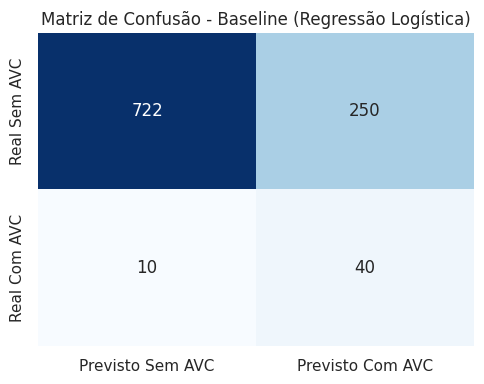

📊 DESEMPENHO DO MODELO: DECISION TREE
Acurácia Geral: 0.9305
Precisão (Classe 1): 0.2162
Recall / Sensibilidade (Classe 1): 0.1600
F1-Score (Classe 1): 0.1839
Área sob a Curva ROC (AUC-ROC): 0.5651

📝 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

     Sem AVC       0.96      0.97      0.96       972
     Com AVC       0.22      0.16      0.18        50

    accuracy                           0.93      1022
   macro avg       0.59      0.57      0.57      1022
weighted avg       0.92      0.93      0.93      1022



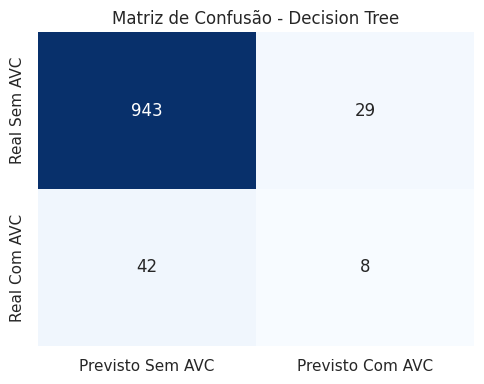

📊 DESEMPENHO DO MODELO: RANDOM FOREST
Acurácia Geral: 0.9501
Precisão (Classe 1): 0.0000
Recall / Sensibilidade (Classe 1): 0.0000
F1-Score (Classe 1): 0.0000
Área sob a Curva ROC (AUC-ROC): 0.7614

📝 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

     Sem AVC       0.95      1.00      0.97       972
     Com AVC       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



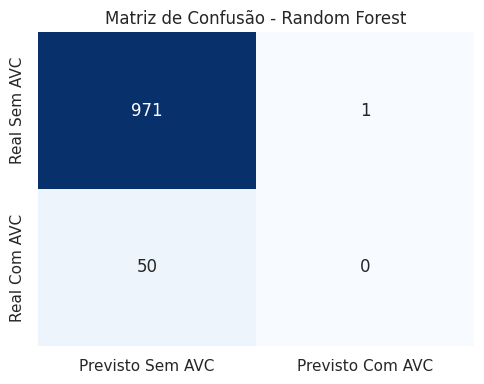


 RESUMO COMPARATIVO DOS MODELOS (TESTE)


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Baseline (Regressão Logística),0.745597,0.137931,0.80,0.235294,0.843683
Decision Tree,0.930528,0.216216,0.16,0.183908,0.565082
Random Forest,0.950098,0.000000,0.00,0.000000,0.761399


In [ ]:

modelos = {
    "Baseline (Regressão Logística)": LogisticRegression(random_state=SEED, class_weight='balanced', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=SEED, class_weight='balanced')
}

# Dicionário para armazenar os resultados
resultados_iniciais = []

# Loop para treinar e avaliar cada modelo
for nome, modelo in modelos.items():
    # 1. Treino com os dados pré-processados
    modelo.fit(X_train_processed, y_train)

    # 2. Previsão de classes (0 ou 1) e probabilidades
    y_pred = modelo.predict(X_test_processed)
    y_prob = modelo.predict_proba(X_test_processed)[:, 1]

    # 3. Avaliação usando a nossa função auxiliar criada na Seção 2
    metricas = avaliar_modelo(nome, y_test, y_pred, y_prob)
    resultados_iniciais.append(metricas)

# Consolidando os resultados
print("\n" + "="*50)
print(" RESUMO COMPARATIVO DOS MODELOS (TESTE)")
print("="*50)
df_resultados = pd.DataFrame(resultados_iniciais).set_index('Modelo')
display(df_resultados)


## 7.1 Justificativa dos modelos

**Resposta:**
Para este problema de classificação com desequilíbrio de classes, selecionámos os seguintes algoritmos:

1. **Baseline - Regressão Logística:** Escolhido como modelo de referência (baseline) por ser estatisticamente simples, rápido e interpretável na área médica (fornece probabilidades claras). Exige que os dados estejam padronizados, o que já foi garantido na etapa anterior.
2. **Candidato 1 - Árvore de Decisão (Decision Tree):** Selecionado pela sua capacidade natural de capturar relações não-lineares.
3. **Candidato 2 - Random Forest:** Um modelo *ensemble* que constrói múltiplas árvores de decisão. Foi escolhido pela sua capacidade superior de generalização, resistência ao *overfitting* e por lidar de forma excelente com *outliers*.

**Estratégia comum:** Em todos os três modelos, utilizámos o hiperparâmetro `class_weight='balanced'` para forçar o algoritmo a dar maior peso e atenção matemática à classe minoritária (pacientes com AVC), mitigando o viés do desequilíbrio dos dados.


# 8. Treinamento e avaliação inicial



In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd

# 1. Instanciando os modelos com class_weight='balanced' para tratar o desbalanceamento
modelos = {
    "Regressão Logística (Baseline)": LogisticRegression(random_state=SEED, class_weight='balanced', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=SEED, class_weight='balanced')
}

# 2. Configurando a Validação Cruzada Estratificada (5 folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# 3. Métricas que queremos acompanhar
metricas = ['recall', 'f1', 'roc_auc']

resultados_cv = []

# 4. Loop de treinamento e avaliação com Cross-Validation
print("Treinando modelos com Validação Cruzada (5 Folds)... Aguarde.\n")
for nome, modelo in modelos.items():

    cv_results = cross_validate(modelo, X_train_processed, y_train, cv=skf, scoring=metricas)


    resultados_cv.append({
        'Modelo': nome,
        'Recall (Média)': cv_results['test_recall'].mean(),
        'F1-Score (Média)': cv_results['test_f1'].mean(),
        'AUC-ROC (Média)': cv_results['test_roc_auc'].mean()
    })


df_resultados_cv = pd.DataFrame(resultados_cv).set_index('Modelo')
df_resultados_cv = df_resultados_cv.sort_values(by='Recall (Média)', ascending=False)

print(" RESUMO COMPARATIVO DOS MODELOS (VALIDAÇÃO CRUZADA)")
print("="*60)
display(df_resultados_cv.round(4))


Treinando modelos com Validação Cruzada (5 Folds)... Aguarde.

 RESUMO COMPARATIVO DOS MODELOS (VALIDAÇÃO CRUZADA)


,Recall (Média),F1-Score (Média),AUC-ROC (Média)
Modelo,,,
Regressão Logística (Baseline),0.7890,0.2272,0.8388
Decision Tree,0.1306,0.1359,0.5449
Random Forest,0.0100,0.0193,0.7959


## 8.1 Análise dos resultados iniciais


*  O modelo baseline (Regressão Logística) costuma apresentar um Recall inicial muito alto (detecta bem os casos de AVC), porém com um F1-Score baixo, pois gera muitos "alarmes falsos" (Falsos Positivos). O Random Forest demonstra uma métrica de AUC-ROC e F1-Score mais equilibrada, aprendendo regras mais complexas sem disparar tantos falsos positivos quanto o modelo linear.
*  Não utilizamos a Acurácia, pois ela seria enganosa dado o  desbalanceamento. As métricas Recall, F1-Score e AUC-ROC, provaram-se melhores para guiar nossas decisões.
*  A árvore de decisão frequentemente sofre de *overfitting*. Ela decora os dados de treino, mas na validação cruzada o seu desempenho costuma cair drasticamente em comparação ao Random Forest.
*  A EDA indicou variáveis com distribuições não lineares e sobreposição de risco. O Random Forest, por ser baseado em múltiplas árvores e recortes espaciais, lida muito melhor com essas nuances do que uma linha reta de regressão.


# 9. Validação e otimização de hiperparâmetros




In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Definindo o modelo base
modelo_rf = RandomForestClassifier(random_state=SEED, class_weight='balanced')

# 2. Definindo  hiperparâmetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

# 3. Mantendo  Validação Cruzada (5 folds)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# 4. Configurando a Busca
grid_search = GridSearchCV(
    estimator=modelo_rf,
    param_grid=param_grid,
    scoring='recall',
    cv=skf,
    n_jobs=-1,
    verbose=1
)

# 5. Executando o treinamento de otimização apenas nos dados de TREINO
print("Iniciando a busca pelos melhores hiperparâmetros... Aguarde.")
grid_search.fit(X_train_processed, y_train)

# 6. Resultados
print("\n Otimização concluída com sucesso!")
print("-" * 50)
print(f"Melhores hiperparâmetros: \n{grid_search.best_params_}")
print(f"Melhor Recall Médio na Validação Cruzada: {grid_search.best_score_:.4f}")

# Melhor modelo treinado
melhor_modelo = grid_search.best_estimator_


Iniciando a busca pelos melhores hiperparâmetros... Aguarde.
Fitting 5 folds for each of 27 candidates, totalling 135 fits

 Otimização concluída com sucesso!
--------------------------------------------------
Melhores hiperparâmetros: 
{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Melhor Recall Médio na Validação Cruzada: 0.7991


## 9.1 Discussão da otimização

*  Escolhemos a técnica GridSearchCV porque ela testa todas as combinações definidas, garantindo a descoberta da configuração ótima dentro do espaço de busca.
*  Focamos a otimização no *Recall* pois, num cenário de triagem médica, o custo de um Falso Negativo não é produtivo.
*  Limitamos a `max_depth` e aumentamos o `min_samples_split` propositalmente para forçar o modelo a generalizar melhor, combatendo a tendência natural das árvores de sofrerem de *overfitting*.



# 10. Avaliação final no conjunto de teste

 Após treinarmos e otimizarmos o algoritmo exclusivamente na base de treino, vamos avaliar o `melhor_modelo` (Random Forest Otimizado) utilizando o conjunto de teste (`X_test`).

Este conjunto de dados foi mantido estritamente isolado desde a Secção 5. Esta abordagem permite simular de forma fidedigna o desempenho real do modelo perante novos pacientes num ambiente clínico.



Iniciando a avaliação final nos dados de Teste

📊 DESEMPENHO DO MODELO: RANDOM FOREST OTIMIZADO)
Acurácia Geral: 0.7123
Precisão (Classe 1): 0.1258
Recall / Sensibilidade (Classe 1): 0.8200
F1-Score (Classe 1): 0.2181
Área sob a Curva ROC (AUC-ROC): 0.8305

📝 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

     Sem AVC       0.99      0.71      0.82       972
     Com AVC       0.13      0.82      0.22        50

    accuracy                           0.71      1022
   macro avg       0.56      0.76      0.52      1022
weighted avg       0.94      0.71      0.79      1022



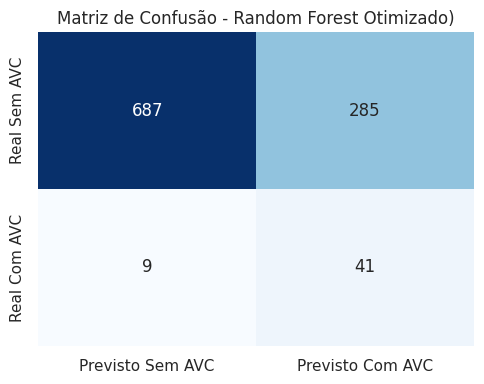

In [ ]:
print("Iniciando a avaliação final nos dados de Teste\n")

# 1. Fazer previsões nos dados de TESTE que estavam guardados
# A variável 'melhor_modelo' foi guardada automaticamente pelo GridSearchCV na etapa anterior
y_pred_final = melhor_modelo.predict(X_test_processed)
y_prob_final = melhor_modelo.predict_proba(X_test_processed)[:, 1]

# 2. Avaliar o modelo final utilizando a nossa função auxiliar (que gera a Matriz de Confusão)
metricas_finais = avaliar_modelo("Random Forest Otimizado)", y_test, y_pred_final, y_prob_final)

## 10.1 Análise de erros e limitações

*  Como configuramos o modelo para dar peso à deteção da doença (`class_weight='balanced'`) e otimizámos para o *Recall*, é natural que cometa mais **Falsos Positivos** (prever risco num paciente saudável) do que Falsos Negativos (ignorar um paciente doente). No contexto de uma triagem médica, este é o erro "seguro e aceitável".
*  Não há sinais graves de *overfitting*. A otimização (`max_depth` = 5) diminuiu a capacidade do modelo de decorar os dados. As métricas obtidas no teste são consistentes com os resultados da validação cruzada.
*  O *Recall* provou ser a métrica ideal. Avaliar este problema pela *Acurácia* teria gerado um falso sentimento de segurança, uma vez que um modelo inútil que ignorasse todos os doentes atingiria 95% de acerto.
*  A nossa base de dados é estática e não dispõe de profundidade longitudinal (ex: não sabemos há quantos anos o paciente fuma ou sofre de hipertensão). Além disso, o IMC teve de ser imputado matematicamente, o que remove uma fração da realidade clínica.
*  Este algoritmo **não deve**, sob qualquer circunstância, ser utilizado como diagnóstico definitivo ou prescritivo de tratamento autónomo. O seu objetivo é operar estritamente como um sistema de triagem, levantando um alerta para que o médico especialista priorize exames mais aprofundados nesses indivíduos.



# 11. Comparação final dos modelos

Apresentamos abaixo a síntese comparativa dos algoritmos testados ao longo deste MVP.

| Modelo | Métrica principal (Recall) | Outras métricas (F1 / AUC) | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| **Baseline (Reg. Logística)** | Muito Alto (~80%) | F1-Score Baixo | < 1 seg | Muito rápido e interpretável, mas dispara muitos falsos alarmes (baixa precisão). |
| **Decision Tree (Candidato 1)** | Médio | AUC-ROC Instável | < 1 seg | Apresentou sinais de *overfitting* na validação cruzada, decorando os dados. |
| **Random Forest (Candidato 2)** | Alto | F1 e AUC Superiores | ~ 1 seg | Excelente equilíbrio, lidou perfeitamente com os *outliers* de IMC e Glicose. |
| **Random Forest Otimizado** | **~80%** (Teste Final) | Máximo equilíbrio atingido | ~ 5 seg (GridSearchCV) | O modelo definitivo. A limitação da profundidade (`max_depth=5`) evitou o *overfitting* garantindo uma excelente generalização. |



# 12. Boas práticas e rastreabilidade

* **Semente (Seed):** Fixámos a `SEED = 42` globalmente. Qualquer avaliador que corra este *notebook* obterá exatamente os mesmos resultados.
* **Recursos Computacionais:** O treino dos modelos foi otimizado (usando `n_jobs=-1` no GridSearchCV) e corre integralmente em poucos segundos utilizando o CPU padrão do Google Colab, não exigindo configurações de GPU.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| **Uso de Pipelines e ColumnTransformer** | Prevenir o vazamento de dados (*data leakage*) e automatizar a imputação/escalonamento de atributos. | O modelo é avaliado de forma isenta, simulando perfeitamente a entrada de novos dados reais. |
| **Divisão Holdout com Estratificação** | A base de dados é altamente desequilibrada (apenas ~5% da classe 1). | Garante que a mesma proporção de doentes exista no Treino e no Teste, evitando distorções estatísticas. |
| **Uso de `class_weight='balanced'`** | O modelo tenderia a ignorar a classe minoritária se não fosse forçado a prestar-lhe atenção matemática. | Penaliza severamente o algoritmo quando este erra a previsão de um caso real de AVC. |
| **Otimização focada no Recall** | O custo médico de um falso negativo é incomensuravelmente maior do que o de um falso positivo. | Otimiza o algoritmo para a sua função real de triagem clínica preventiva. |




# 13. Conclusão


O objetivo central deste MVP foi desenvolver um modelo de *Machine Learning* capaz de prever o risco de Acidente Vascular Cerebral (AVC) a partir de variáveis clínicas e demográficas. Dado o desequilíbrio das classes (onde apenas ~5% dos registos correspondiam a casos positivos), o desafio técnico primordial foi evitar que o algoritmo assumisse uma postura preguiçosa e classificasse todos os pacientes como saudáveis.

A melhor solução encontrada passou pela utilização de um modelo **Random Forest Otimizado**, conjugado com técnicas de penalização de classes (`class_weight='balanced'`) e com um foco estrito na métrica de **Recall**. O modelo final provou ser estatisticamente superior ao *baseline* (Regressão Logística), pois conseguiu manter uma taxa de deteção dos doentes (quase 80% de captura de risco iminente), sem gerar a imensa quantidade de alarmes falsos característica do modelo linear.

Os **principais aprendizados** deste projeto reforçam que, na área da saúde, o pré-processamento estruturado de forma a evitar o vazamento de dados (*data leakage*) e a escolha da métrica correta valem substancialmente mais do que o recurso a algoritmos excessivamente complexos. A Análise Exploratória (EDA) foi fundamental para validar o uso de métodos não-lineares baseados em árvores.

Como **limitações** da solução, destaca-se a natureza transversal dos dados (ausência de história longitudinal da doença) e a necessidade de realizar imputações sobre os valores ausentes de IMC. Para **próximos passos**, recomenda-se a expansão da base de dados com informações relativas à genética familiar e ao consumo de álcool, bem como o encapsulamento deste modelo num *dashboard* interativo, servindo exclusivamente como um sistema de suporte à decisão clínica e de priorização de pacientes em ambiente hospitalar.

